In [75]:
import pandas as pd
import numpy as np
import datetime

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

In [76]:
# Hiển thị đẹp hơn trong notebook
pd.set_option('display.max_columns', None)

# Hiện toàn bộ dòng
pd.set_option('display.max_rows', None)

# Giới hạn độ rộng nhìn đẹp hơn
pd.set_option('display.width', 1500)

# Độ dài nội dung ô
pd.set_option('display.max_colwidth', 30)

# Format số đẹp
pd.options.display.float_format = '{:.2f}'.format

In [77]:
file_path = "TỔNG HỢP ĐIỂM K58KTP.xlsx"

df = pd.read_excel(
    file_path,
    header=None,
    dtype=object
)

print("Kích thước dữ liệu gốc:")
print(df.shape)

Kích thước dữ liệu gốc:
(56, 74)


In [78]:
# MSSV
student_ids = df.iloc[1, 3:].tolist()

# Tên sinh viên
student_names = df.iloc[2, 3:].tolist()

# Tên môn học
courses = df.iloc[4:, 2].tolist()

# Bảng điểm
grades = df.iloc[4:, 3:].copy()

# Đặt tên môn làm index
grades.index = courses

print("Số sinh viên:", len(student_ids))
print("Số môn học:", len(courses))

Số sinh viên: 71
Số môn học: 52


In [79]:
def clean_score(x):

    # Nếu Excel lưu thành ngày
    if isinstance(x, (pd.Timestamp, datetime.datetime)):
        return float(x.day)

    # Ô trống
    if pd.isna(x):
        return np.nan

    try:
        return float(x)

    except:
        return np.nan


# Làm sạch dữ liệu
grades = grades.apply(
    lambda col: col.map(clean_score)
)

In [80]:
student_df = grades.T

student_df.columns = courses

student_df.insert(
    0,
    "MSSV",
    student_ids
)

student_df.insert(
    1,
    "Tên sinh viên",
    student_names
)

print("Kích thước dữ liệu sau xử lý:")
print(student_df.shape)

student_df

Kích thước dữ liệu sau xử lý:
(71, 54)


,MSSV,Tên sinh viên,Kỹ thuật lập trình nâng cao,Trí tuệ nhân tạo và học máy,Xử lý ảnh,Thực tập chuyên ngành Công nghệ phần mềm,Công nghệ phần mềm,Quản lý dự án công nghệ thông tin,An toàn và bảo mật thông tin,Phát triển ứng dụng trên nền web,Lập trình Python,Quản trị mạng,Hệ quản trị cơ sở dữ liệu,Đồ án phân tích thiết kế hệ thống,Phân tích và thiết kế hệ thống,Tư tưởng Hồ Chí Minh,Marketing,Đồ án mạng máy tính,Thiết bị truyền thông và mạng máy tính,Hệ điều hành,Cấu trúc dữ liệu và giải thuật,Lập trình hướng đối tượng,Mạng máy tính,Cơ sở dữ liệu,Phương pháp NCKH,Chuyển đổi số,Đồ án hệ thống nhúng,Kiến trúc máy tính,Xác suất thống kê,Lịch sử Đảng cộng sản Việt Nam,Thiết kế logic số,Xử lý tín hiệu số,Toán rời rạc,Giải tích 2,Tiếng Anh 3,Môi trường CN và phát triển bền vững,Pháp luật đại cương,Giao tiếp kỹ thuật,Tin học trong kỹ thuật,Bóng chuyền 1,Hệ thống nhúng,Vi xử lý – Vi điều khiển,Toán 2(Giải tích 1),Chủ nghĩa xã hội khoa học,Bóng rổ 1,Đại số tuyến tính,Vật lý 1,Kinh tế chính trị Mác - Lênin,Tiếng Anh 2,Quản lý chất lượng,Nhập môn về KT máy tính,Giáo dục thể chất bắt buộc,Triết học Mác - Lênin,Tiếng Anh 1
3,K225480106002,Nguyễn Tuấn Anh,2.00,3.00,1.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,1.00,2.00,3.00,3.00,1.00,3.00,3.00,2.00,3.00,2.00,NaN,1.00,2.00,2.00,2.00,1.00,3.00,1.00,2.00,1.00,1.00,3.00,2.00,NaN,1.00,2.00,2.00,2.00,2.00,2.00,1.00,3.00,2.00,1.00,2.00,2.00,3.00,3.00
4,K225480106095,Nguyễn Tuấn Anh,3.00,2.00,1.00,3.00,NaN,3.00,3.70,3.70,3.70,2.00,3.50,1.50,3.00,NaN,2.00,2.00,2.00,3.50,2.00,3.50,1.50,3.00,2.50,2.00,2.00,1.50,2.00,2.00,3.00,2.00,NaN,1.00,NaN,3.00,2.00,2.50,2.00,NaN,3.00,2.50,1.00,3.00,2.00,1.50,1.50,1.00,3.00,2.00,2.00,1.50,3.00,1.00
5,K225510201001,Bùi Ngọc Anh,3.00,2.00,3.00,2.00,2.00,3.00,2.00,1.00,3.00,2.00,3.00,1.00,3.00,2.00,3.00,2.00,2.00,2.00,1.00,3.00,NaN,2.00,3.00,2.00,NaN,1.00,NaN,1.00,NaN,NaN,NaN,NaN,3.00,2.00,1.00,3.00,2.00,NaN,2.00,1.00,NaN,2.00,NaN,3.00,NaN,1.00,2.00,NaN,NaN,NaN,1.00,3.00
6,K225480106082,Vũ Việt Anh,3.00,3.00,2.50,NaN,3.00,3.50,3.70,2.50,3.50,2.00,3.50,3.00,3.00,2.00,2.00,3.00,1.50,2.50,2.50,3.00,1.50,1.00,3.50,2.00,3.50,NaN,2.00,4.00,2.00,1.00,3.00,1.00,1.50,1.50,1.50,3.00,1.00,NaN,1.00,1.00,1.50,3.70,NaN,1.00,1.00,2.50,1.00,NaN,3.00,1.00,2.00,1.00
7,K225480106001,Lê Tuấn Anh,3.00,3.00,2.00,3.00,3.00,3.50,3.70,3.70,3.70,2.50,3.50,3.50,3.00,3.00,2.00,2.00,2.50,3.00,2.00,3.00,2.00,1.50,3.00,2.50,NaN,3.00,2.00,3.70,1.00,1.00,3.70,1.00,NaN,3.00,3.00,3.00,1.00,NaN,2.50,1.50,3.00,3.50,3.00,3.00,2.00,1.00,2.50,1.00,2.00,2.50,1.00,1.00
8,K225480106100,Lý Văn Cường,3.00,3.00,3.50,4.00,3.50,3.70,3.70,3.70,4.00,3.70,3.50,3.00,3.70,2.50,3.00,3.00,3.00,3.00,3.00,4.00,3.00,3.00,3.70,3.50,3.50,4.00,2.50,3.00,1.00,2.50,3.50,2.00,3.50,3.70,3.00,3.00,3.00,1.00,3.00,3.00,2.00,2.50,3.50,2.50,2.00,3.00,4.00,1.00,2.00,2.50,1.00,3.50
9,K225480106008,Nguyễn Khánh Duy,3.00,3.70,1.00,3.00,2.00,3.00,2.00,3.50,3.00,1.00,3.50,3.00,2.00,1.00,2.50,2.00,3.00,3.00,2.50,3.00,2.00,1.00,1.50,2.00,2.50,3.00,3.00,2.50,2.50,3.00,3.70,3.70,2.00,2.50,2.00,2.00,3.00,NaN,2.50,4.00,2.00,3.00,1.00,2.00,3.00,2.50,2.00,3.00,3.50,2.00,3.00,4.00
10,K225480106007,Nguyễn Thế Dương,3.00,4.00,3.50,3.00,3.50,3.50,3.70,3.70,3.70,3.00,3.70,3.50,3.00,3.50,2.50,3.70,3.00,2.00,2.00,3.50,2.50,2.00,3.50,3.00,3.00,2.50,1.00,3.00,2.50,1.00,3.50,2.50,1.00,3.00,3.00,3.00,1.50,NaN,3.00,2.00,2.00,3.00,1.00,2.00,1.00,2.00,3.00,2.50,3.00,3.70,1.00,2.00
11,K225480106093,Nguyễn Đức Dương,3.00,4.00,3.00,3.00,3.50,3.50,3.70,3.70,3.70,3.70,3.50,3.50,3.00,4.00,3.70,3.70,3.70,3.00,2.50,3.50,3.00,3.70,3.70,3.00,3.70,3.00,3.50,3.00,2.50,3.00,3.70,3.70,2.50,3.70,3.00,3.00,3.70,NaN,2.50,2.00,4.00,3.00,2.50,4.00,3.50,3.50,3.00,2.00,3.00,2.50,3.00,2.50
12,K225480106003,Đặng Đình Đạt,2.50,3.00,3.70,3.50,3.00,4.00,3.70,3.70,3.70,3.00,4.00,3.00,3.70,3.50,2.00,3.00,3.00,3.00,2.50,4.00,3.00,3.00,3.70,3.50,3.50,3.00,3.00,3.00,2.00,2.00,3.70,3.00,1.50,1.50,2.50,3.50,4.00,NaN,3.70,3.00,2.50,3.00,3.00,2.00,1.00,1.00,1.00,2.00,3.00,3.00,2.50,1

In [81]:
missing = student_df.isnull().sum()

missing[missing > 0]

Kỹ thuật lập trình nâng cao                  8
Trí tuệ nhân tạo và học máy                  8
Xử lý ảnh                                    8
Thực tập chuyên ngành Công nghệ phần mềm     9
Công nghệ phần mềm                          10
Quản lý dự án công nghệ thông tin            9
An toàn và bảo mật thông tin                 9
Phát triển ứng dụng trên nền web             9
Lập trình Python                             9
Quản trị mạng                                9
Hệ quản trị cơ sở dữ liệu                    9
Đồ án phân tích thiết kế hệ thống            9
Phân tích và thiết kế hệ thống               9
Tư tưởng Hồ Chí Minh                         9
Marketing                                    8
Đồ án mạng máy tính                          9
Thiết bị truyền thông và mạng máy tính       8
Hệ điều hành                                10
Cấu trúc dữ liệu và giải thuật              10
Lập trình hướng đối tượng                    9
Mạng máy tính                               10
Cơ sở dữ liệu

In [82]:
X = student_df.drop(
    columns=[
        "MSSV",
        "Tên sinh viên"
    ]
)

# Điền dữ liệu thiếu
imputer = SimpleImputer(
    strategy='mean'
)

X_imputed = imputer.fit_transform(X)

# Chuẩn hóa dữ liệu
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_imputed
)

print(X_scaled.shape)

(71, 52)


In [83]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    X_scaled
)

student_df["Cluster"] = clusters

student_df[
    [
        "MSSV",
        "Tên sinh viên",
        "Cluster"
    ]
]

,MSSV,Tên sinh viên,Cluster
3,K225480106002,Nguyễn Tuấn Anh,1
4,K225480106095,Nguyễn Tuấn Anh,1
5,K225510201001,Bùi Ngọc Anh,1
6,K225480106082,Vũ Việt Anh,1
7,K225480106001,Lê Tuấn Anh,2
8,K225480106100,Lý Văn Cường,2
9,K225480106008,Nguyễn Khánh Duy,1
10,K225480106007,Nguyễn Thế Dương,2
11,K225480106093,Nguyễn Đức Dương,0
12,K225480106003,Đặng Đình Đạt,2


In [84]:
score = silhouette_score(
    X_scaled,
    clusters
)

print(
    "Silhouette Score:",
    round(score, 4)
)

Silhouette Score: 0.0922


In [85]:
student_df["Điểm TB"] = X.mean(axis=1)

student_df[
    [
        "Tên sinh viên",
        "Điểm TB"
    ]
]

,Tên sinh viên,Điểm TB
3,Nguyễn Tuấn Anh,2.22
4,Nguyễn Tuấn Anh,2.30
5,Bùi Ngọc Anh,2.11
6,Vũ Việt Anh,2.24
7,Lê Tuấn Anh,2.50
8,Lý Văn Cường,2.99
9,Nguyễn Khánh Duy,2.55
10,Nguyễn Thế Dương,2.70
11,Nguyễn Đức Dương,3.24
12,Đặng Đình Đạt,2.87


In [86]:
cluster_mean = student_df.groupby(
    "Cluster"
)["Điểm TB"].mean()

cluster_mean

Cluster
0   3.15
1   2.31
2   2.71
Name: Điểm TB, dtype: float64

In [97]:
# Điểm trung bình theo nhóm học lực
group_avg = student_df.groupby(
    "Nhóm học lực"
)["Điểm TB"].mean()

print("Điểm trung bình từng nhóm:")

group_avg

Điểm trung bình từng nhóm:


Nhóm học lực
Cần cải thiện   2.31
Học tốt         3.15
Trung bình      2.71
Name: Điểm TB, dtype: float64

In [87]:
sorted_clusters = cluster_mean.sort_values()

mapping = {
    sorted_clusters.index[0]:
        "Cần cải thiện",

    sorted_clusters.index[1]:
        "Trung bình",

    sorted_clusters.index[2]:
        "Học tốt"
}

student_df["Nhóm học lực"] = (
    student_df["Cluster"]
    .map(mapping)
)

student_df[
    [
        "MSSV",
        "Tên sinh viên",
        "Điểm TB",
        "Nhóm học lực"
    ]
]

,MSSV,Tên sinh viên,Điểm TB,Nhóm học lực
3,K225480106002,Nguyễn Tuấn Anh,2.22,Cần cải thiện
4,K225480106095,Nguyễn Tuấn Anh,2.30,Cần cải thiện
5,K225510201001,Bùi Ngọc Anh,2.11,Cần cải thiện
6,K225480106082,Vũ Việt Anh,2.24,Cần cải thiện
7,K225480106001,Lê Tuấn Anh,2.50,Trung bình
8,K225480106100,Lý Văn Cường,2.99,Trung bình
9,K225480106008,Nguyễn Khánh Duy,2.55,Cần cải thiện
10,K225480106007,Nguyễn Thế Dương,2.70,Trung bình
11,K225480106093,Nguyễn Đức Dương,3.24,Học tốt
12,K225480106003,Đặng Đình Đạt,2.87,Trung bình


In [88]:
student_df[
    "Nhóm học lực"
].value_counts()

Nhóm học lực
Trung bình       28
Cần cải thiện    24
Học tốt          19
Name: count, dtype: int64

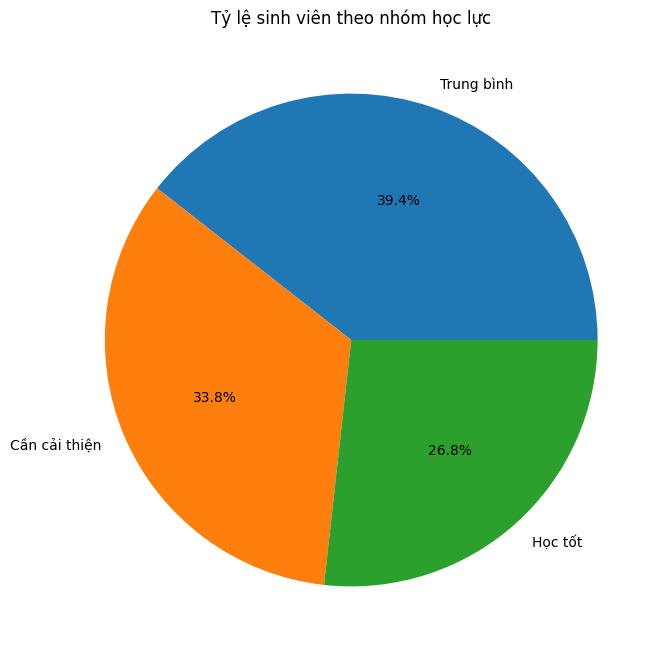

In [89]:
group_counts = student_df[
    "Nhóm học lực"
].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    group_counts,
    labels=group_counts.index,
    autopct='%1.1f%%'
)

plt.title(
    "Tỷ lệ sinh viên theo nhóm học lực"
)

plt.show()

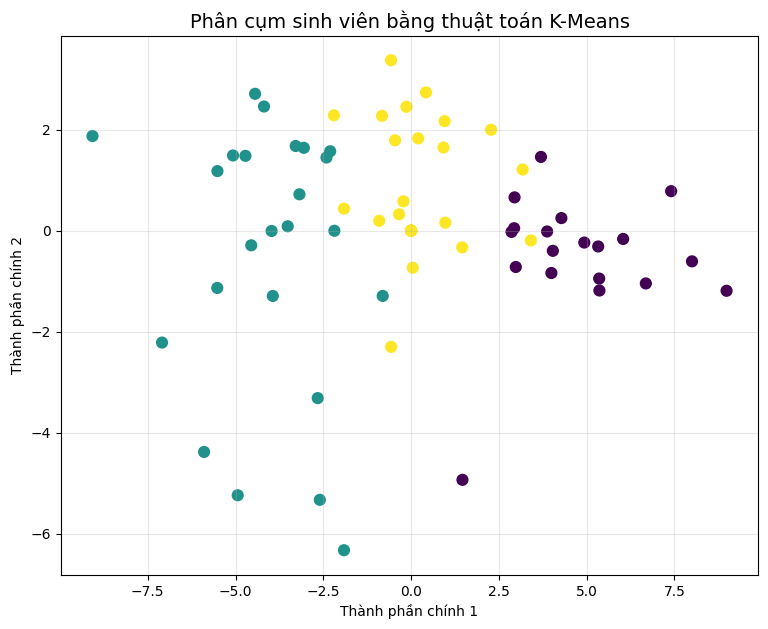

In [96]:
from sklearn.decomposition import PCA
# Giảm chiều dữ liệu
pca = PCA(n_components=2)

X_pca = pca.fit_transform(
    X_scaled
)

plt.figure(figsize=(9, 7), facecolor='white')

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap='viridis',
    s=60
)

plt.title(
    "Phân cụm sinh viên bằng thuật án K-Means",
    fontsize=14
)
plt.xlabel("Thành phần chính 1")
plt.ylabel("Thành phần chính 2")

plt.grid(alpha=0.3)

plt.show()

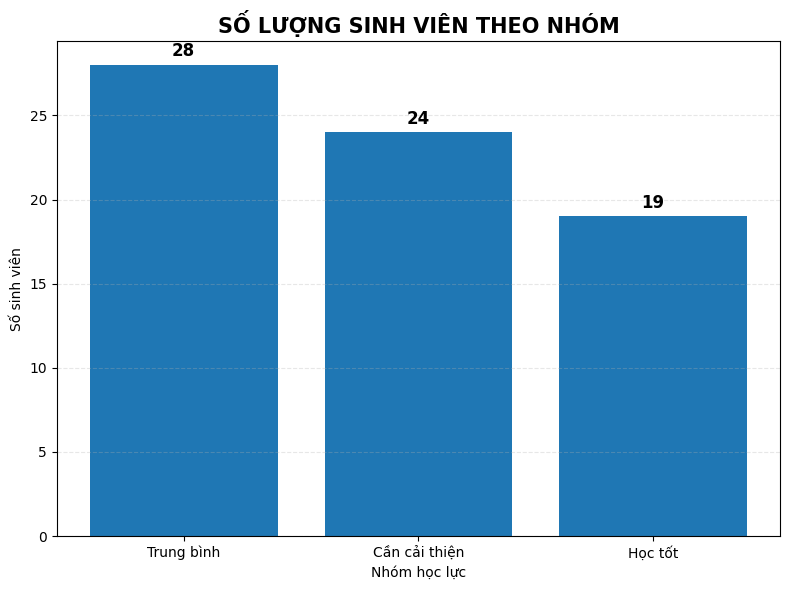

In [91]:
group_counts = student_df[
    "Nhóm học lực"
].value_counts()

plt.style.use('default')

fig, ax = plt.subplots(
    figsize=(8, 6),
    facecolor='white'
)

bars = ax.bar(
    group_counts.index,
    group_counts.values
)

# Hiện số lên đầu cột
for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{int(height)}',
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

plt.title(
    "SỐ LƯỢNG SINH VIÊN THEO NHÓM",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel(
    "Nhóm học lực"
)

plt.ylabel(
    "Số sinh viên"
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [92]:
from openpyxl import load_workbook
from openpyxl.styles import (
    PatternFill,
    Font,
    Border,
    Side,
    Alignment
)

from openpyxl.chart import (
    PieChart,
    BarChart,
    Reference
)

# --------------------------
# Lưu file
# --------------------------
file_name = "ket_qua_phan_cum.xlsx"

student_df.to_excel(
    file_name,
    index=False
)

# --------------------------
# Mở file Excel
# --------------------------
wb = load_workbook(file_name)
ws = wb.active

ws.title = "KetQuaPhanCum"

# ==================================================
# STYLE
# ==================================================

# Header xanh
header_fill = PatternFill(
    start_color="5B9BD5",
    end_color="5B9BD5",
    fill_type="solid"
)

# Xen kẽ dòng
odd_fill = PatternFill(
    start_color="EAF2F8",
    end_color="EAF2F8",
    fill_type="solid"
)

even_fill = PatternFill(
    start_color="FFFFFF",
    end_color="FFFFFF",
    fill_type="solid"
)

# Màu nhóm học lực
blue_fill = PatternFill(
    start_color="4E79A7",
    end_color="4E79A7",
    fill_type="solid"
)

red_fill = PatternFill(
    start_color="E15759",
    end_color="E15759",
    fill_type="solid"
)

green_fill = PatternFill(
    start_color="59A14F",
    end_color="59A14F",
    fill_type="solid"
)

# Font
header_font = Font(
    bold=True,
    color="FFFFFF"
)

white_font = Font(
    color="FFFFFF",
    bold=True
)

# Border
thin_border = Border(
    left=Side(style='thin'),
    right=Side(style='thin'),
    top=Side(style='thin'),
    bottom=Side(style='thin')
)

# ==================================================
# HEADER
# ==================================================
for cell in ws[1]:
    cell.fill = header_fill
    cell.font = header_font
    cell.border = thin_border
    cell.alignment = Alignment(
        horizontal='center',
        vertical='center'
    )

# ==================================================
# TÔ MÀU BẢNG
# ==================================================
for row in range(2, ws.max_row + 1):

    fill = odd_fill if row % 2 == 0 else even_fill

    for col in range(1, ws.max_column + 1):

        cell = ws.cell(row=row, column=col)

        cell.fill = fill
        cell.border = thin_border

# ==================================================
# TÔ MÀU NHÓM HỌC LỰC
# ==================================================
group_col = None

for col in ws[1]:
    if col.value == "Nhóm học lực":
        group_col = col.column
        break

for row in range(2, ws.max_row + 1):

    cell = ws.cell(
        row=row,
        column=group_col
    )

    if cell.value == "Trung bình":
        cell.fill = blue_fill
        cell.font = white_font

    elif cell.value == "Cần cải thiện":
        cell.fill = red_fill
        cell.font = white_font

    elif cell.value == "Học tốt":
        cell.fill = green_fill
        cell.font = white_font

# ==================================================
# TỰ CHỈNH ĐỘ RỘNG CỘT
# ==================================================
for column in ws.columns:

    max_length = 0
    column_letter = column[0].column_letter

    for cell in column:

        try:
            if cell.value:
                max_length = max(
                    max_length,
                    len(str(cell.value))
                )
        except:
            pass

    ws.column_dimensions[
        column_letter
    ].width = max_length + 2

# ==================================================
# FREEZE HEADER
# ==================================================
ws.freeze_panes = "A2"

# ==================================================
# THỐNG KÊ NHÓM
# ==================================================
group_counts = student_df[
    "Nhóm học lực"
].value_counts()

# Tiêu đề bảng thống kê
ws["BJ1"] = "Nhóm học lực"
ws["BK1"] = "Số lượng"

# Style header thống kê
ws["BJ1"].fill = header_fill
ws["BK1"].fill = header_fill

ws["BJ1"].font = header_font
ws["BK1"].font = header_font

row = 2

for group, count in group_counts.items():

    ws[f"BJ{row}"] = group
    ws[f"BK{row}"] = count

    row += 1

# ==================================================
# DỮ LIỆU CHART
# ==================================================
labels = Reference(
    ws,
    min_col=62,   # BJ
    min_row=2,
    max_row=row-1
)

data = Reference(
    ws,
    min_col=63,   # BK
    min_row=1,
    max_row=row-1
)

# ==================================================
# BIỂU ĐỒ HÌNH TRÒN
# ==================================================
pie = PieChart()

pie.add_data(
    data,
    titles_from_data=True
)

pie.set_categories(labels)

pie.title = (
    "Tỷ lệ sinh viên "
    "theo nhóm học lực"
)

pie.width = 11
pie.height = 8

ws.add_chart(
    pie,
    "BM2"
)

# ==================================================
# BIỂU ĐỒ CỘT
# ==================================================
bar = BarChart()

bar.add_data(
    data,
    titles_from_data=True
)

bar.set_categories(labels)

bar.title = (
    "Số lượng sinh viên "
    "theo nhóm"
)

bar.y_axis.title = "Số lượng"
bar.x_axis.title = "Nhóm học lực"

bar.width = 11
bar.height = 8

ws.add_chart(
    bar,
    "BM20"
)

# ==================================================
# SAVE
# ==================================================
wb.save(file_name)

print(
    f"Đã lưu file {file_name}"
)

Đã lưu file ket_qua_phan_cum.xlsx
